Decision Tree (full) - Train Acc: 1.000, Test Acc: 0.971
Decision Tree (max_depth=3) - Train Acc: 0.858, Test Acc: 0.805
Random Forest - Train Acc: 1.000, Test Acc: 0.981
5-Fold CV Decision Tree (depth=3) Mean Acc: 0.830 (+/- 0.021)
5-Fold CV Random Forest Mean Acc: 0.997 (+/- 0.006)


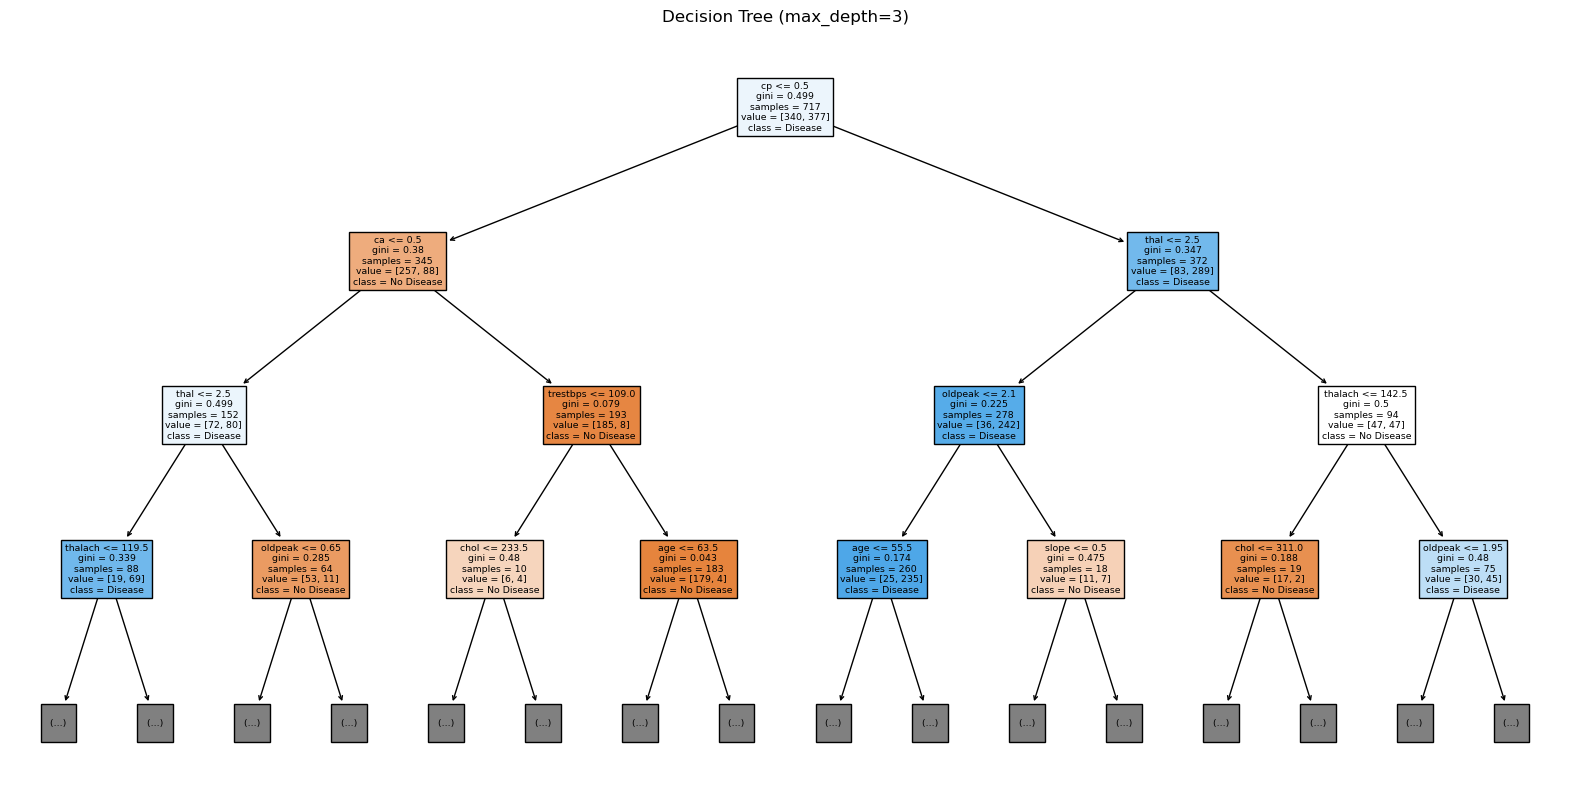

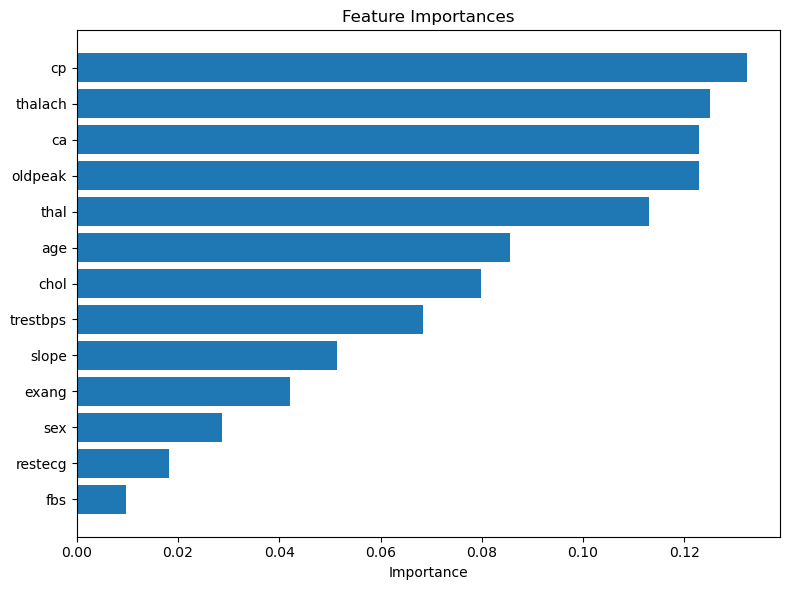

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Load and prepare the data

def load_data(path=r"C:\Users\Thrishaa J\Downloads\heart.csv"):
    df = pd.read_csv(path)
    X = df.drop('target', axis=1)
    y = df['target']
    return X, y

# 2. Train/Test split

def split_data(X, y, test_size=0.3, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

# 3. Decision Tree

def train_decision_tree(X_train, y_train, max_depth=None, random_state=42):
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    dt.fit(X_train, y_train)
    return dt

# 4. Random Forest

def train_random_forest(X_train, y_train, random_state=42):
    rf = RandomForestClassifier(random_state=random_state)
    rf.fit(X_train, y_train)
    return rf

# 5. Evaluate

def evaluate_model(model, X_train, y_train, X_test, y_test):
    return model.score(X_train, y_train), model.score(X_test, y_test)

# 6. Cross-Validation

def cross_val(model, X, y, cv=5):
    scores = cross_val_score(model, X, y, cv=cv)
    return scores.mean(), scores.std()

# 7. Visualize Decision Tree
def visualize_tree(model, feature_names, class_names, max_depth=3):
    plt.figure(figsize=(20, 10))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        max_depth=max_depth
    )
    plt.title(f"Decision Tree (max_depth={max_depth})")
    plt.show()

# 8. Plot Feature Importances
def plot_feature_importance(importances, feature_names):
    sorted_idx = importances.argsort()
    plt.figure(figsize=(8, 6))
    plt.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx])
    plt.xlabel('Importance')
    plt.title('Feature Importances')
    plt.tight_layout()
    plt.show()

# 9. Main routine

def main():
    X, y = load_data()
    X_train, X_test, y_train, y_test = split_data(X, y)

    # Decision Tree (full)
    dt_full = train_decision_tree(X_train, y_train)
    dt_full_train_acc, dt_full_test_acc = evaluate_model(dt_full, X_train, y_train, X_test, y_test)

    # Decision Tree (depth=3)
    dt3 = train_decision_tree(X_train, y_train, max_depth=3)
    dt3_train_acc, dt3_test_acc = evaluate_model(dt3, X_train, y_train, X_test, y_test)

    # Random Forest
    rf = train_random_forest(X_train, y_train)
    rf_train_acc, rf_test_acc = evaluate_model(rf, X_train, y_train, X_test, y_test)

    # Cross-validation
    cv_dt3_mean, cv_dt3_std = cross_val(dt3, X, y)
    cv_rf_mean, cv_rf_std = cross_val(rf, X, y)

    # Print results
    print(f"Decision Tree (full) - Train Acc: {dt_full_train_acc:.3f}, Test Acc: {dt_full_test_acc:.3f}")
    print(f"Decision Tree (max_depth=3) - Train Acc: {dt3_train_acc:.3f}, Test Acc: {dt3_test_acc:.3f}")
    print(f"Random Forest - Train Acc: {rf_train_acc:.3f}, Test Acc: {rf_test_acc:.3f}")
    print(f"5-Fold CV Decision Tree (depth=3) Mean Acc: {cv_dt3_mean:.3f} (+/- {cv_dt3_std:.3f})")
    print(f"5-Fold CV Random Forest Mean Acc: {cv_rf_mean:.3f} (+/- {cv_rf_std:.3f})")

    # Visualizations
    visualize_tree(dt_full, X.columns, ['No Disease', 'Disease'], max_depth=3)

    importances = rf.feature_importances_
    plot_feature_importance(importances, X.columns)

if __name__ == '__main__':
    main()
